# Tugas Minggu 1 - Analisis Kualitas Air Smart Aqua

Pengerjaan Minggu 1 (analisis deskriptif dan diagnostik) untuk studi
kasus budidaya nila intensif.


## Setup

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 12
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

DATA_PATH = "../data/smart_aqua_synthetic_water_quality.csv"

WATER_QUALITY = [
    "temperature_c", "ph", "dissolved_oxygen_mg_l",
    "ammonia_mg_l", "nitrite_mg_l", "turbidity_ntu",
]
print("Setup selesai.")

Setup selesai.


---
# A. Audit Kualitas Data

### A.1 Membaca CSV: dimensi, periode, jumlah kolam, dan interval pencatatan

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
df = df.sort_values(["pond_id", "timestamp"]).reset_index(drop=True)

n_rows, n_cols = df.shape
t_min, t_max = df["timestamp"].min(), df["timestamp"].max()
n_pond = df["pond_id"].nunique()
interval = df.groupby("pond_id")["timestamp"].diff().dropna().mode().iloc[0]

print(f"Jumlah baris          : {n_rows:,}")
print(f"Jumlah kolam          : {n_cols} kolom | {n_pond} kolam -> {sorted(df['pond_id'].unique())}")
print(f"Periode pengamatan    : {t_min} s/d {t_max} ({(t_max - t_min).days + 1} hari)")
print(f"Interval pencatatan   : {interval}")
df.head()

Jumlah baris          : 23,040
Jumlah kolam          : 26 kolom | 8 kolam -> ['P01', 'P02', 'P03', 'P04', 'P05', 'P06', 'P07', 'P08']
Periode pengamatan    : 2026-01-05 00:00:00 s/d 2026-03-05 23:30:00 (60 hari)
Interval pencatatan   : 0 days 00:30:00


,record_id,timestamp,pond_id,day_of_cycle,hour_decimal,time_period,species,pond_volume_m3,stocking_density_kg_m3,biomass_kg,temperature_c,ph,dissolved_oxygen_mg_l,ammonia_mg_l,nitrite_mg_l,turbidity_ntu,feed_kg,aerator_command,aerator_status,aerator_fault,rainfall_mm,water_exchange_pct,sensor_quality_flag,fish_stress_event,risk_next_3h,dataset_split
0,AQUA-000001,2026-01-05 00:00:00,P01,1,0.0,dawn,Nila,52,15.77,820.0,27.20,7.20,5.59,0.160,0.132,38.6,0.0,ON,ON,0,0.0,0,OK,0,0.0,TRAIN
1,AQUA-000002,2026-01-05 00:30:00,P01,1,0.5,dawn,Nila,52,15.77,820.0,26.99,7.19,5.61,0.156,0.159,30.8,0.0,ON,ON,0,0.0,0,OK,0,0.0,TRAIN
2,AQUA-000003,2026-01-05 01:00:00,P01,1,1.0,dawn,Nila,52,15.77,820.0,26.76,7.17,5.55,0.177,0.161,33.7,0.0,ON,ON,0,0.0,0,OK,0,0.0,TRAIN
3,AQUA-000004,2026-01-05 01:30:00,P01,1,1.5,dawn,Nila,52,15.77,820.0,27.13,7.16,5.55,NaN,0.142,29.6,0.0,ON,ON,0,0.0,0,SENSOR_MISSING,0,0.0,TRAIN
4,AQUA-000005,2026-01-05 02:00:00,P01,1,2.0,dawn,Nila,52,15.77,820.0,26.99,7.12,5.52,0.150,0.136,28.7,0.0,ON,ON,0,0.0,0,OK,0,0.0,TRAIN


Hasil pembacaan menunjukkan data berisi 23.040 baris dan 26 kolom, mencakup 8 kolam selama
60 hari (5 Jan - 5 Mar 2026) dengan interval pencatatan 30 menit. Angka ini cocok dengan
hitungan manual kami: 8 kolam x 60 hari x 48 observasi per hari = 23.040 baris, jadi dari
sisi dimensi datanya terlihat utuh.

### A.2 Pengecekan duplikasi dan kelengkapan urutan waktu

In [3]:
print("record_id unik :", df["record_id"].is_unique,
      "| duplikat :", int(df["record_id"].duplicated().sum()))
print("kombinasi pond_id-timestamp unik :", not df.duplicated(["pond_id", "timestamp"]).any(),
      "| duplikat :", int(df.duplicated(["pond_id", "timestamp"]).sum()))

ringkasan = []
for pond, g in df.groupby("pond_id"):
    ts = g["timestamp"].sort_values()
    diffs = ts.diff().dropna()
    ringkasan.append({
        "pond_id": pond,
        "n_observasi": len(g),
        "awal": ts.min(),
        "akhir": ts.max(),
        "interval_dominan": diffs.mode().iloc[0],
        "n_jeda_bukan_30m": int((diffs != pd.Timedelta(minutes=30)).sum()),
    })
pd.DataFrame(ringkasan)

record_id unik : True | duplikat : 0
kombinasi pond_id-timestamp unik : True | duplikat : 0


,pond_id,n_observasi,awal,akhir,interval_dominan,n_jeda_bukan_30m
0,P01,2880,2026-01-05,2026-03-05 23:30:00,0 days 00:30:00,0
1,P02,2880,2026-01-05,2026-03-05 23:30:00,0 days 00:30:00,0
2,P03,2880,2026-01-05,2026-03-05 23:30:00,0 days 00:30:00,0
3,P04,2880,2026-01-05,2026-03-05 23:30:00,0 days 00:30:00,0
4,P05,2880,2026-01-05,2026-03-05 23:30:00,0 days 00:30:00,0
5,P06,2880,2026-01-05,2026-03-05 23:30:00,0 days 00:30:00,0
6,P07,2880,2026-01-05,2026-03-05 23:30:00,0 days 00:30:00,0
7,P08,2880,2026-01-05,2026-03-05 23:30:00,0 days 00:30:00,0


Tidak ada `record_id` yang terduplikasi, dan pasangan `pond_id`-`timestamp` juga semuanya
unik. Tiap kolam punya 2.880 observasi dengan selisih waktu yang selalu tepat 30 menit, tidak
ada lompatan waktu. Jadi urutan waktunya lengkap dan konsisten. Satu hal yang perlu
diperhatikan: nilai sensor yang kosong tidak menghilangkan barisnya, melainkan tetap ada
sebagai `NaN` sambil ditandai flag. Jadi kekosongan data di sini bukan berupa baris yang
terhapus.

### A.3 Tabel tipe data, jumlah nilai hilang, nilai unik, min, dan max

In [4]:
audit = pd.DataFrame({
    "variabel": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing": df.isna().sum().values,
    "missing_pct": (df.isna().mean() * 100).values,
    "n_unik": df.nunique(dropna=True).values,
    "min": [df[c].min() if pd.api.types.is_numeric_dtype(df[c]) else np.nan for c in df.columns],
    "max": [df[c].max() if pd.api.types.is_numeric_dtype(df[c]) else np.nan for c in df.columns],
})
audit["missing_pct"] = audit["missing_pct"].round(3)
audit

,variabel,dtype,missing,missing_pct,n_unik,min,max
0,record_id,str,0,0.000,23040,NaN,NaN
1,timestamp,datetime64[us],0,0.000,2880,NaN,NaN
2,pond_id,str,0,0.000,8,NaN,NaN
3,day_of_cycle,int64,0,0.000,60,1.000,60.000
4,hour_decimal,float64,0,0.000,48,0.000,23.500
5,time_period,str,0,0.000,4,NaN,NaN
6,species,str,0,0.000,1,NaN,NaN
7,pond_volume_m3,int64,0,0.000,7,45.000,54.000
8,stocking_density_kg_m3,float64,0,0.000,424,15.770,39.260
9,biomass_kg,float64,0,0.000,438,820.000,1845.400


Nilai yang hilang ternyata hanya ada di kolom sensor: `ph` 41 (0,18%), DO 38 (0,16%),
turbidity 38 (0,16%), dan amonia 32 (0,14%). Target `risk_next_3h` juga punya 48 nilai
kosong, yaitu 6 observasi terakhir di tiap kolam karena horizon 3 jamnya belum lengkap.
Totalnya kecil sekali, di bawah 0,25%. Variabel seperti `time_period`, `aerator_status`, dan
`sensor_quality_flag` hanya punya beberapa nilai unik karena memang berisi label.

### A.4 Frekuensi `sensor_quality_flag` dan contoh spike, flatline, drift, missing

In [5]:
flag_summary = (
    df["sensor_quality_flag"].value_counts()
    .rename_axis("sensor_quality_flag").reset_index(name="count")
)
flag_summary["percentage"] = (flag_summary["count"] / len(df) * 100).round(2)
flag_summary

,sensor_quality_flag,count,percentage
0,OK,22356,97.03
1,PH_DRIFT,327,1.42
2,SENSOR_MISSING,147,0.64
3,DO_FLATLINE,145,0.63
4,DO_SPIKE,61,0.26
5,MULTIPLE,4,0.02


In [6]:
missing_row = df[WATER_QUALITY].isna().any(axis=1)
pd.crosstab(df["sensor_quality_flag"], missing_row.rename("ada_missing"))

ada_missing,False,True
sensor_quality_flag,,
DO_FLATLINE,145,0
DO_SPIKE,61,0
MULTIPLE,2,2
OK,22356,0
PH_DRIFT,327,0
SENSOR_MISSING,0,147


In [7]:
spike_rows = df[df["sensor_quality_flag"] == "DO_SPIKE"]
print(f"Jumlah DO_SPIKE: {len(spike_rows)} | rentang DO: "
      f"{spike_rows['dissolved_oxygen_mg_l'].min():.2f} s/d "
      f"{spike_rows['dissolved_oxygen_mg_l'].max():.2f} mg/L")
spike_rows[["record_id", "timestamp", "pond_id", "dissolved_oxygen_mg_l"]].head(8)

Jumlah DO_SPIKE: 61 | rentang DO: -0.99 s/d 15.88 mg/L


,record_id,timestamp,pond_id,dissolved_oxygen_mg_l
1255,AQUA-001256,2026-01-31 03:30:00,P01,-0.93
1744,AQUA-001745,2026-02-10 08:00:00,P01,12.69
1921,AQUA-001922,2026-02-14 00:30:00,P01,13.85
2049,AQUA-002050,2026-02-16 16:30:00,P01,-0.73
2187,AQUA-002188,2026-02-19 13:30:00,P01,-0.67
2345,AQUA-002346,2026-02-22 20:30:00,P01,11.71
2371,AQUA-002372,2026-02-23 09:30:00,P01,-0.25
3199,AQUA-003200,2026-01-11 15:30:00,P02,13.22


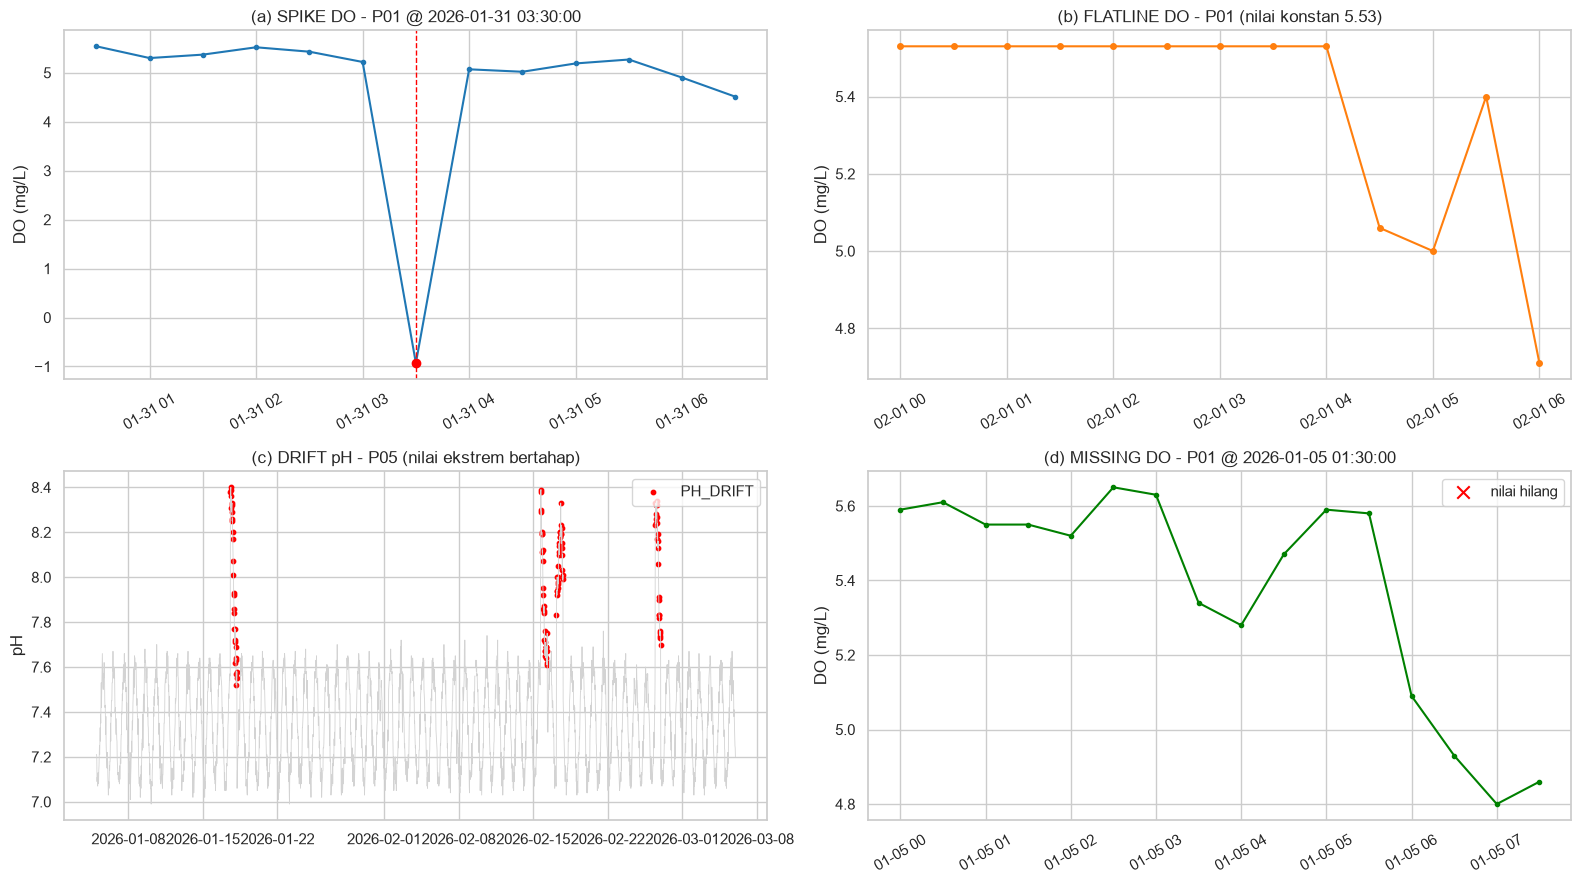

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

# (a) SPIKE: +/- 3 jam di sekitar satu lonjakan
sp = spike_rows.iloc[0]
w = df[(df["pond_id"] == sp["pond_id"]) &
       (df["timestamp"].between(sp["timestamp"] - pd.Timedelta(hours=3),
                                sp["timestamp"] + pd.Timedelta(hours=3)))]
axes[0, 0].plot(w["timestamp"], w["dissolved_oxygen_mg_l"], marker="o", ms=3, color="#1f77b4")
axes[0, 0].axvline(sp["timestamp"], color="red", ls="--", lw=1)
axes[0, 0].scatter(sp["timestamp"], sp["dissolved_oxygen_mg_l"], color="red", zorder=5)
axes[0, 0].set_title(f"(a) SPIKE DO - {sp['pond_id']} @ {sp['timestamp']}")
axes[0, 0].set_ylabel("DO (mg/L)")
axes[0, 0].tick_params(axis="x", rotation=30)

# (b) FLATLINE: DO konstan pada P01, 1 Feb 2026 00:00-06:00
fl = df[(df["pond_id"] == "P01") &
        (df["timestamp"].between("2026-02-01 00:00", "2026-02-01 06:00"))]
axes[0, 1].plot(fl["timestamp"], fl["dissolved_oxygen_mg_l"], marker="o", ms=4, color="#ff7f0e")
axes[0, 1].set_title("(b) FLATLINE DO - P01 (nilai konstan 5.53)")
axes[0, 1].set_ylabel("DO (mg/L)")
axes[0, 1].tick_params(axis="x", rotation=30)

# (c) DRIFT: pH P05; titik merah = baris ber-flag PH_DRIFT
d = df[df["pond_id"] == "P05"]
dr = d[d["sensor_quality_flag"] == "PH_DRIFT"]
axes[1, 0].plot(d["timestamp"], d["ph"], lw=0.6, color="lightgray")
axes[1, 0].scatter(dr["timestamp"], dr["ph"], s=10, color="red", label="PH_DRIFT")
axes[1, 0].set_title("(c) DRIFT pH - P05 (nilai ekstrem bertahap)")
axes[1, 0].set_ylabel("pH")
axes[1, 0].legend(loc="upper right")

# (d) MISSING: nilai DO yang hilang pada salah satu kolam
mp = df[df[WATER_QUALITY].isna().any(axis=1)].iloc[0]
mm = df[(df["pond_id"] == mp["pond_id"]) &
        (df["timestamp"].between(mp["timestamp"] - pd.Timedelta(hours=6),
                                 mp["timestamp"] + pd.Timedelta(hours=6)))]
axes[1, 1].plot(mm["timestamp"], mm["dissolved_oxygen_mg_l"], marker="o", ms=3, color="green")
na = mm[mm["dissolved_oxygen_mg_l"].isna()]
axes[1, 1].scatter(na["timestamp"], [mm["dissolved_oxygen_mg_l"].min()] * len(na),
                   marker="x", s=80, color="red", label="nilai hilang")
axes[1, 1].set_title(f"(d) MISSING DO - {mp['pond_id']} @ {mp['timestamp']}")
axes[1, 1].set_ylabel("DO (mg/L)")
axes[1, 1].legend(loc="upper right")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

Sebagian besar data berstatus OK, yaitu 97,03%. Sisanya adalah anomali yang sudah ditandai:
PH_DRIFT 327 (1,42%), SENSOR_MISSING 147 (0,64%), DO_FLATLINE 145 (0,63%), DO_SPIKE 61
(0,26%), dan MULTIPLE 4 (0,02%). Dari tabel dan grafik contoh, kami menemukan:

- Spike: DO melonjak ke angka yang tidak wajar, rentangnya -0,99 sampai 15,88 mg/L, dan
  hanya muncul di satu titik. Ini bisa merusak statistik nilai ekstrem.
- Flatline: DO yang benar-benar datar, contohnya di P01 konstan 5,53 selama beberapa jam.
  Ciri khas sensor macet.
- Drift: pH di P05 perlahan bergeser sampai 8,4, padahal rata-rata kolamnya sekitar 7,37.
- Missing: nilai kosong hanya ada pada baris ber-flag SENSOR_MISSING dan 2 baris MULTIPLE,
  dan cuma di kolom sensor.

Dari crosstab terlihat SENSOR_MISSING selalu berpasangan dengan nilai kosong, sedangkan
MULTIPLE hanya sebagian (2 dari 4). Jadi flag ini cukup bisa dipercaya sebagai penanda
kualitas data.

### A.5 Aturan yang kami pakai untuk nilai sensor bermasalah

In [9]:
sensor_missing = df[WATER_QUALITY].isna().any(axis=1)
sensor_flagged = df["sensor_quality_flag"].isin(
    ["DO_SPIKE", "DO_FLATLINE", "PH_DRIFT", "SENSOR_MISSING", "MULTIPLE"]
)

print(f"Baris dengan nilai sensor hilang : {sensor_missing.sum()}")
print(f"Baris ber-flag selain OK         : {sensor_flagged.sum()} "
      f"({sensor_flagged.mean() * 100:.2f}%)")

df_clean = df.loc[~sensor_flagged].copy()
print(f"Baris 'bersih' (tanpa flag)      : {len(df_clean):,} "
      f"({len(df_clean) / len(df) * 100:.2f}%)")

Baris dengan nilai sensor hilang : 149
Baris ber-flag selain OK         : 684 (2.97%)
Baris 'bersih' (tanpa flag)      : 22,356 (97.03%)


Sebelum masuk analisis, kami sepakati dulu perlakuan untuk data yang bermasalah. Intinya
dibedakan per tahap supaya tidak asal buang:

Tahap deskriptif: semua baris tetap dipakai, statistik dihitung dengan `dropna()` per kolom.
Selain itu kami bandingkan juga dengan versi tanpa baris ber-flag (`df_clean`) sebagai uji
sensitivitas, supaya kelihatan seberapa besar pengaruh flag ke kesimpulan.

Tahap diagnostik: baris ber-flag tetap dipertahankan, dan `sensor_quality_flag` justru kami
jadikan variabel kontrol. Alasannya, flag itu sendiri membawa informasi. Misalnya DO_SPIKE
memang muncul di dekat nilai ekstrem, jadi kalau dihapus justru bisa membuang sinyal kejadian.

Tahap prediktif (Minggu 2): flag akan diubah jadi fitur indikator. Imputasi dan standardisasi
dilatih hanya dari data TRAIN lewat pipeline, dan baris `risk_next_3h` yang kosong tidak
dipakai untuk latih. Ini untuk menghindari kebocoran data.

Prinsip yang kami pegang: file CSV sumber tidak diubah, dan semua keputusan pembersihan kami
tulis eksplisit supaya bisa direproduksi.

---
# B. Descriptive Analytics: Apa yang Terjadi?

### B.1 Statistik deskriptif parameter kualitas air

In [10]:
desc = []
for col in WATER_QUALITY:
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    mean, std = s.mean(), s.std()
    desc.append({
        "parameter": col,
        "n": s.size,
        "mean": mean,
        "median": s.median(),
        "std": std,
        "min": s.min(),
        "Q1": q1,
        "Q3": q3,
        "max": s.max(),
        "IQR": q3 - q1,
        "CV (%)": (std / mean * 100) if mean != 0 else np.nan,
    })
desc = pd.DataFrame(desc)
desc.round(3)

,parameter,n,mean,median,std,min,Q1,Q3,max,IQR,CV (%)
0,temperature_c,23040,28.601,28.600,1.240,25.840,27.530,29.670,31.650,2.140,4.335
1,ph,22999,7.353,7.350,0.182,6.920,7.210,7.490,8.400,0.280,2.470
2,dissolved_oxygen_mg_l,23002,5.206,5.160,0.886,-0.990,4.630,5.760,15.880,1.130,17.018
3,ammonia_mg_l,23008,0.336,0.333,0.088,0.110,0.273,0.398,0.593,0.125,26.014
4,nitrite_mg_l,23040,0.281,0.274,0.079,0.103,0.217,0.337,0.527,0.120,28.279
5,turbidity_ntu,23002,49.340,48.700,7.814,26.100,43.600,54.600,80.700,11.000,15.837


Kalau dilihat dari jarak mean-median dan IQR-nya:

- Suhu dan pH paling stabil (CV sekitar 4,3% dan 2,5%), distribusinya hampir simetris.
- DO, amonia, nitrit, dan kekeruhan lebih berfluktuasi (CV 15-28%).
- Amonia dan nitrit mean-nya kecil (0,336 dan 0,281 mg/L), jadi CV terlihat besar padahal
  variasi absolutnya tidak. Ini contoh kasus di mana CV = std/mean kurang tepat: kalau mean
  mendekati nol (apalagi sama dengan nol) penyebut yang kecil membuat rasionya membengkak,
  walau rentang nilainya tidak selebar itu. Untuk parameter sekecil amonia/nitrit kami lebih
  memakai IQR, simpangan baku absolut, atau membandingkannya dengan ambang risiko.

Kami juga menghitung ulang statistiknya setelah baris ber-flag dibuang (sel berikutnya) untuk
memastikan flag tidak mendominasi kesimpulan.

In [11]:
desc_clean = []
for col in WATER_QUALITY:
    s = df_clean[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    desc_clean.append({
        "parameter": col, "mean": s.mean(), "std": s.std(),
        "min": s.min(), "max": s.max(), "IQR": q3 - q1,
    })
cols = ["mean", "std", "min", "max"]
base = desc.set_index("parameter")[cols]
clean = pd.DataFrame(desc_clean).set_index("parameter")[cols]
sens = (base - clean)
sens.columns = [f"selisih_{c} (semua - bersih)" for c in sens.columns]
sens.round(4)

,selisih_mean (semua - bersih),selisih_std (semua - bersih),selisih_min (semua - bersih),selisih_max (semua - bersih)
parameter,,,,
temperature_c,0.0038,0.0015,0.0,0.0
ph,0.0094,0.0179,0.0,0.6
dissolved_oxygen_mg_l,0.0099,0.0932,-3.5,7.9
ammonia_mg_l,-0.0002,-0.0003,0.0,0.0
nitrite_mg_l,-0.0001,-0.0002,0.0,0.0
turbidity_ntu,-0.0001,-0.0146,0.0,0.0


### B.2 Perbandingan statistik per kolam, time_period, jam, dan fase siklus

In [12]:
pond_quality = df.groupby("pond_id")[WATER_QUALITY].mean().round(3)
pond_quality

,temperature_c,ph,dissolved_oxygen_mg_l,ammonia_mg_l,nitrite_mg_l,turbidity_ntu
pond_id,,,,,,
P01,28.138,7.353,5.447,0.248,0.202,42.065
P02,28.439,7.356,5.310,0.315,0.258,47.387
P03,28.639,7.344,5.043,0.388,0.327,54.412
P04,28.541,7.355,5.151,0.342,0.285,49.468
P05,29.139,7.371,5.222,0.337,0.278,49.167
P06,28.738,7.350,4.905,0.425,0.362,56.941
P07,28.336,7.345,5.453,0.267,0.221,43.842
P08,28.840,7.353,5.115,0.368,0.311,51.400


In [13]:
period_quality = df.groupby("time_period")[WATER_QUALITY].mean().round(3)
period_quality

,temperature_c,ph,dissolved_oxygen_mg_l,ammonia_mg_l,nitrite_mg_l,turbidity_ntu
time_period,,,,,,
afternoon,30.060,7.550,6.087,0.335,0.278,49.507
dawn,27.143,7.158,4.459,0.335,0.282,47.401
morning,28.528,7.346,4.934,0.330,0.280,50.168
night,28.674,7.360,5.342,0.346,0.282,50.286


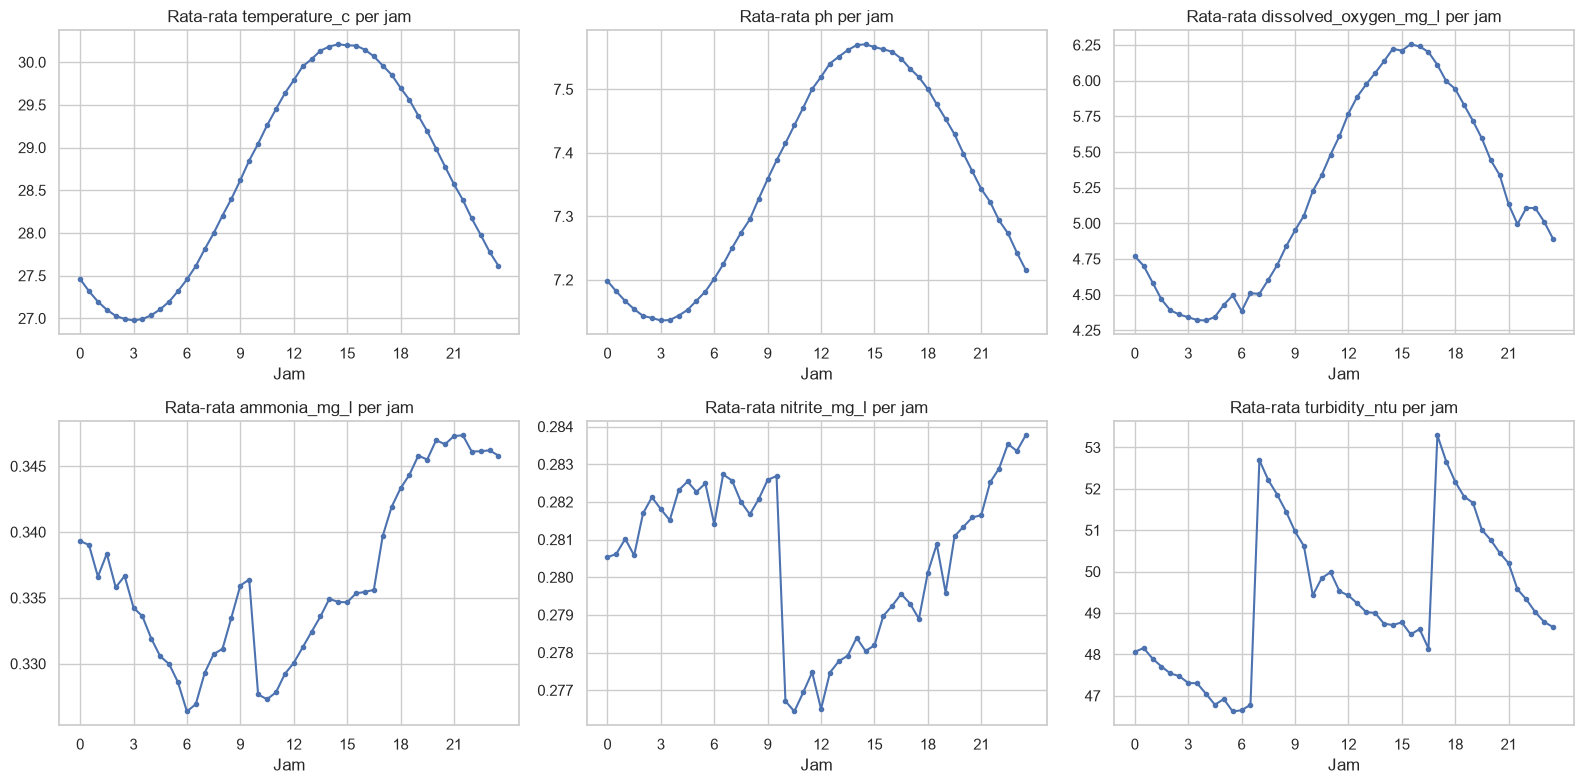

In [14]:
hourly_mean = df.groupby("hour_decimal")[WATER_QUALITY].mean()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, WATER_QUALITY):
    ax.plot(hourly_mean.index, hourly_mean[col], marker="o", ms=3)
    ax.set_title(f"Rata-rata {col} per jam")
    ax.set_xlabel("Jam")
    ax.set_xticks(range(0, 24, 3))
plt.tight_layout()
plt.show()

In [15]:
def cycle_phase(day):
    if day <= 20:
        return "Awal"
    if day <= 40:
        return "Tengah"
    return "Akhir"

df["cycle_phase"] = df["day_of_cycle"].apply(cycle_phase)
phase_quality = (
    df.groupby("cycle_phase")[WATER_QUALITY].mean()
    .reindex(["Awal", "Tengah", "Akhir"]).round(3)
)
phase_quality

,temperature_c,ph,dissolved_oxygen_mg_l,ammonia_mg_l,nitrite_mg_l,turbidity_ntu
cycle_phase,,,,,,
Awal,28.778,7.358,5.344,0.269,0.218,43.350
Tengah,28.627,7.349,5.225,0.337,0.278,49.026
Akhir,28.399,7.354,5.048,0.404,0.346,55.653


Beberapa hal yang kami catat:

- Per kolam: P06 paling menonjol dengan amonia (0,425), nitrit (0,362), dan kekeruhan (56,9)
  tertinggi serta DO terendah (4,91). P01 dan P07 paling bersih (amonia sekitar 0,25; nitrit
  sekitar 0,20; kekeruhan 42-44). Suhu tertinggi ada di P05 (29,1 C).
- Per time_period: DO tertinggi waktu afternoon (6,09) dan terendah waktu dawn (4,46). pH
  polanya sama, tertinggi siang (7,55) dan terendah dawn (7,16). Ini wajar untuk siklus
  fotosintesis dan respirasi.
- Per jam: kurva DO membentuk siklus harian, naik dari pagi, puncak sore, lalu turun malam
  dan minimum menjelang fajar.
- Per fase siklus: dari fase Awal ke Akhir, amonia (0,269 ke 0,404), nitrit (0,218 ke 0,346),
  dan kekeruhan (43,4 ke 55,7) naik konsisten, sedangkan DO turun (5,34 ke 5,05). Sepertinya
  ini efek biomassa yang makin besar seiring waktu.

### B.3 Parameter paling stabil dan paling berfluktuasi

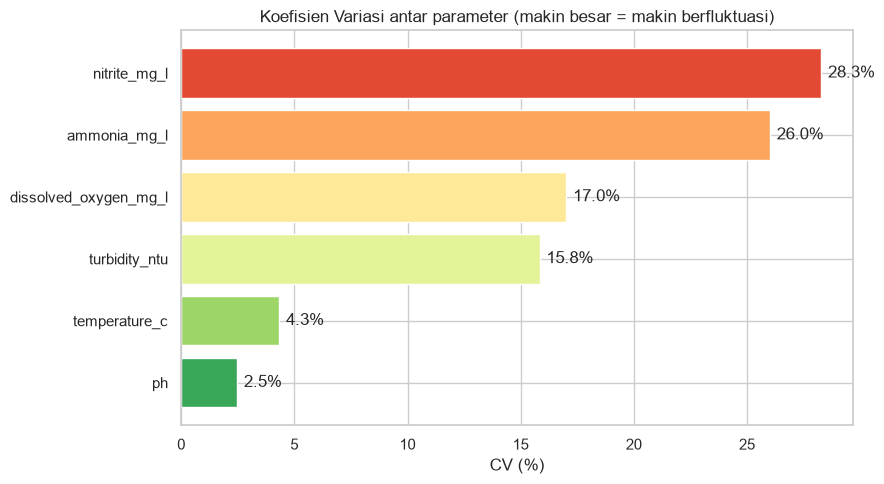

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
rank = desc.set_index("parameter")["CV (%)"].sort_values()
colors = sns.color_palette("RdYlGn_r", len(rank))
ax.barh(rank.index, rank.values, color=colors)
ax.set_title("Koefisien Variasi antar parameter (makin besar = makin berfluktuasi)")
ax.set_xlabel("CV (%)")
for i, v in enumerate(rank.values):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center")
plt.tight_layout()
plt.show()

Dari grafik CV, urutannya cukup jelas. Yang paling stabil adalah ph (CV 2,5%) dan
temperature_c (4,3%), keduanya bergerak di rentang sempit. Yang paling berfluktuasi adalah
nitrite_mg_l (28,3%), ammonia_mg_l (26,0%), lalu dissolved_oxygen_mg_l (17,0%) dan
turbidity_ntu (15,8%).

Tapi hati-hati, CV tinggi di amonia/nitrit sebagian cuma artefak mean yang kecil; variasi
absolutnya sendiri cuma sekitar IQR 0,12-0,13 mg/L. Jadi kami tidak mau menyimpulkan hanya
dari CV, harus dibaca bareng IQR. Menurut kami parameter yang paling perlu diperhatikan
pengelola tetap DO dan nitrit, karena keduanya berfluktuasi dan langsung memicu kondisi
berisiko.

### B.4 Frekuensi kondisi berisiko (DO, amonia, nitrit) per kolam dan per jam

Ambang yang dipakai sesuai tugas:

- DO < 3,5 mg/L
- amonia > 0,55 mg/L
- nitrit > 0,35 mg/L

In [17]:
df["risk_do"] = df["dissolved_oxygen_mg_l"] < 3.5
df["risk_nh3"] = df["ammonia_mg_l"] > 0.55
df["risk_no2"] = df["nitrite_mg_l"] > 0.35
df["risk_condition"] = df["risk_do"] | df["risk_nh3"] | df["risk_no2"]

print("Jumlah observasi berisiko :", int(df["risk_condition"].sum()),
      f"({df['risk_condition'].mean() * 100:.2f}%)")
print("Pemicu (jumlah baris):")
print(f"  DO   < 3,5 : {int(df['risk_do'].sum())}")
print(f"  NH3  > 0,55: {int(df['risk_nh3'].sum())}")
print(f"  NO2  > 0,35: {int(df['risk_no2'].sum())}")

Jumlah observasi berisiko : 4849 (21.05%)
Pemicu (jumlah baris):
  DO   < 3,5 : 181
  NH3  > 0,55: 105
  NO2  > 0,35: 4795


In [18]:
risk_by_pond = (
    df.groupby("pond_id")["risk_condition"]
    .agg(risk_count="sum", risk_rate="mean")
)
risk_by_pond["risk_pct"] = (risk_by_pond["risk_rate"] * 100).round(3)
risk_by_pond[["risk_count", "risk_pct"]].sort_values("risk_pct", ascending=False)

,risk_count,risk_pct
pond_id,,
P06,1590,55.208
P03,1132,39.306
P08,982,34.097
P04,571,19.826
P05,382,13.264
P02,172,5.972
P07,16,0.556
P01,4,0.139


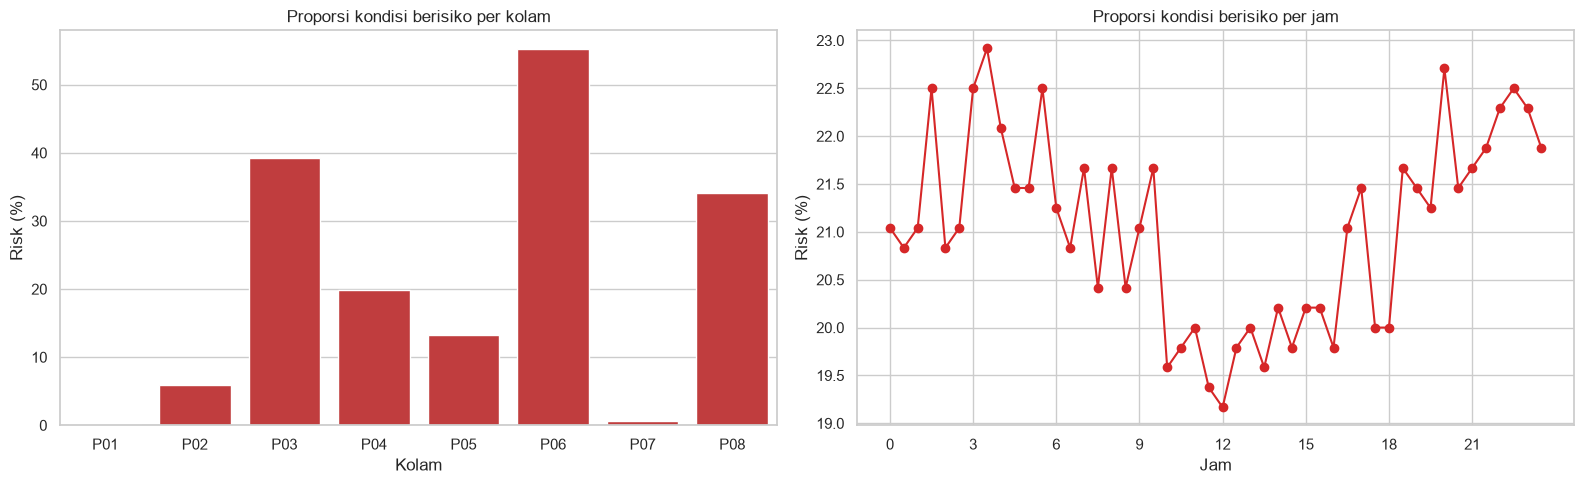

In [19]:
risk_by_hour = df.groupby("hour_decimal")["risk_condition"].mean().mul(100)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=risk_by_pond.reset_index(), x="pond_id", y="risk_pct",
            ax=axes[0], color="#d62728")
axes[0].set_title("Proporsi kondisi berisiko per kolam")
axes[0].set_ylabel("Risk (%)")
axes[0].set_xlabel("Kolam")

axes[1].plot(risk_by_hour.index, risk_by_hour.values, marker="o", color="#d62728")
axes[1].set_title("Proporsi kondisi berisiko per jam")
axes[1].set_xlabel("Jam")
axes[1].set_ylabel("Risk (%)")
axes[1].set_xticks(range(0, 24, 3))
plt.tight_layout()
plt.show()

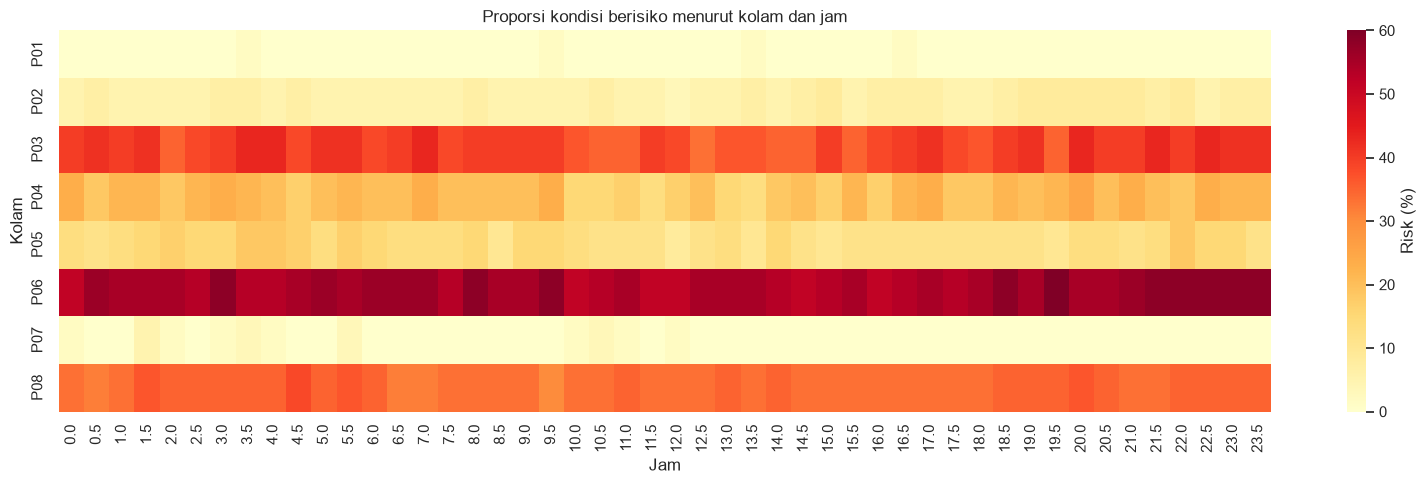

In [20]:
risk_heatmap = (
    df.groupby(["pond_id", "hour_decimal"])["risk_condition"].mean().unstack() * 100
)
plt.figure(figsize=(16, 5))
sns.heatmap(risk_heatmap, cmap="YlOrRd", cbar_kws={"label": "Risk (%)"})
plt.title("Proporsi kondisi berisiko menurut kolam dan jam")
plt.xlabel("Jam")
plt.ylabel("Kolam")
plt.tight_layout()
plt.show()

Kondisi berisiko muncul di 4.849 observasi atau 21,05%. Pemicu yang paling sering adalah
nitrit > 0,35 mg/L (4.795 baris), sedangkan amonia (105) dan DO rendah (181) jarang.

Per kolam, P06 paling berisiko (55,2%), lalu P03 (39,3%) dan P08 (34,1%). P01 (0,14%) dan
P07 (0,56%) paling aman.

Per jam proporsinya justru relatif datar, sekitar 19-23%, cuma sedikit naik di dini hari.
Menurut kami ini menunjukkan perbedaan antar-kolam jauh lebih besar daripada perbedaan
antar-jam, jadi risikonya lebih ditentukan kondisi kolam (biomassa/kepadatan) daripada jam.
Heatmap juga menunjukkan blok P03, P06, P08 tetap merah di hampir semua jam, bukan cuma di
jam tertentu.

### B.5 Distribusi kejadian stres ikan (`fish_stress_event`)

In [21]:
stress_summary = df["fish_stress_event"].value_counts().sort_index()
print("Total kejadian stres :", int(df["fish_stress_event"].sum()))
stress_by_pond = df.groupby("pond_id")["fish_stress_event"].agg(
    stress_count="sum", stress_rate="mean")
stress_by_pond["stress_pct"] = (stress_by_pond["stress_rate"] * 100).round(3)

stress_by_hour = df.groupby("hour_decimal")["fish_stress_event"].mean().mul(100)

display(stress_by_pond[["stress_count", "stress_pct"]].sort_values("stress_count", ascending=False))
display(stress_by_hour.sort_values(ascending=False).head(10).round(3))

Total kejadian stres : 47


,stress_count,stress_pct
pond_id,,
P03,9,0.312
P01,8,0.278
P05,7,0.243
P06,7,0.243
P04,6,0.208
P08,4,0.139
P02,3,0.104
P07,3,0.104


hour_decimal
22.0    0.625
1.5     0.625
8.0     0.625
12.0    0.417
14.0    0.417
11.5    0.417
8.5     0.417
19.0    0.417
17.5    0.417
10.5    0.417
Name: fish_stress_event, dtype: float64

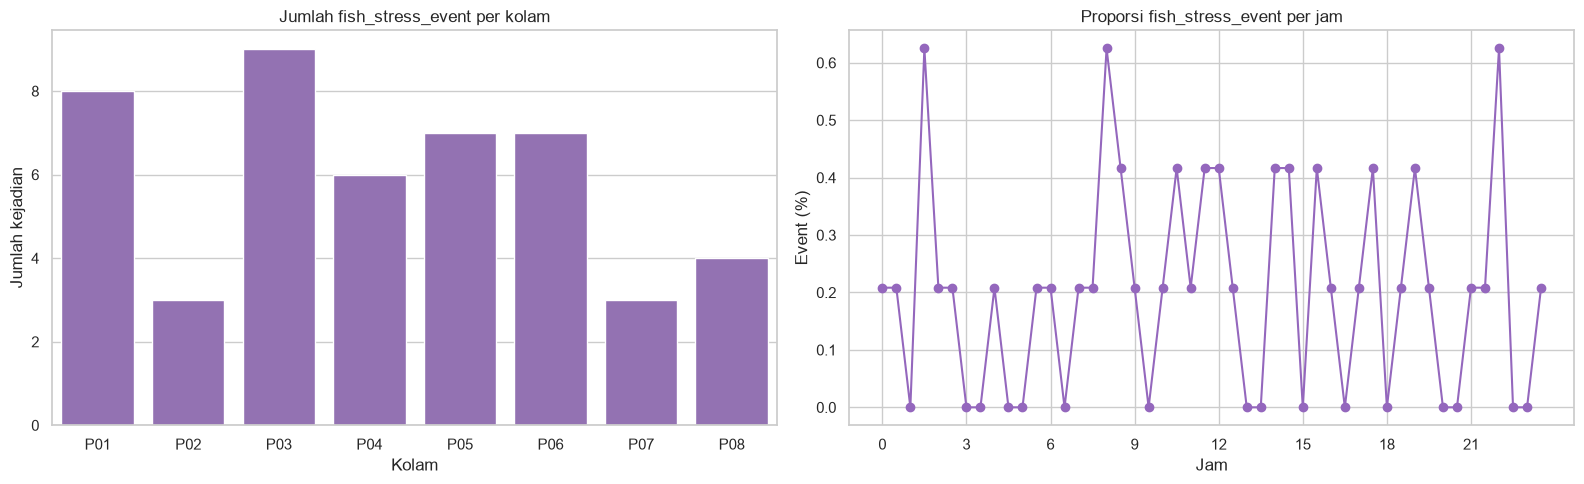

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=stress_by_pond.reset_index(), x="pond_id", y="stress_count",
            ax=axes[0], color="#9467bd")
axes[0].set_title("Jumlah fish_stress_event per kolam")
axes[0].set_ylabel("Jumlah kejadian")
axes[0].set_xlabel("Kolam")

axes[1].plot(stress_by_hour.index, stress_by_hour.values, marker="o", color="#9467bd")
axes[1].set_title("Proporsi fish_stress_event per jam")
axes[1].set_xlabel("Jam")
axes[1].set_ylabel("Event (%)")
axes[1].set_xticks(range(0, 24, 3))
plt.tight_layout()
plt.show()

Dari total 23.040 observasi, hanya 47 (0,20%) yang ditandai fish_stress_event. Sebarannya
hampir merata antar kolam (P03 = 9, P01 = 8, terendah P02 dan P07 masing-masing 3) dan tidak
selalu ada di kolam berisiko tinggi. Contohnya P06 yang risiko kondisinya paling tinggi (55%)
justru cuma punya 7 event. Jam dengan event terbanyak adalah 22:00, 01:30, dan 08:00,
masing-masing 0,63%.

Menurut kami event stres ini lebih tepat dianggap penanda kejadian, bukan prediktor. Jumlahnya
sedikit dan tidak sejalan sempurna dengan kondisi air, jadi sesuai ketentuan tugas kami
gunakan hanya untuk deskriptif/diagnostik dan tidak dipakai sebagai fitur model.

---
# C. Diagnostic Analytics: Mengapa Terjadi?

### C.1 Risiko antar kolam: apakah terkait biomassa, kepadatan, suhu, atau waktu?

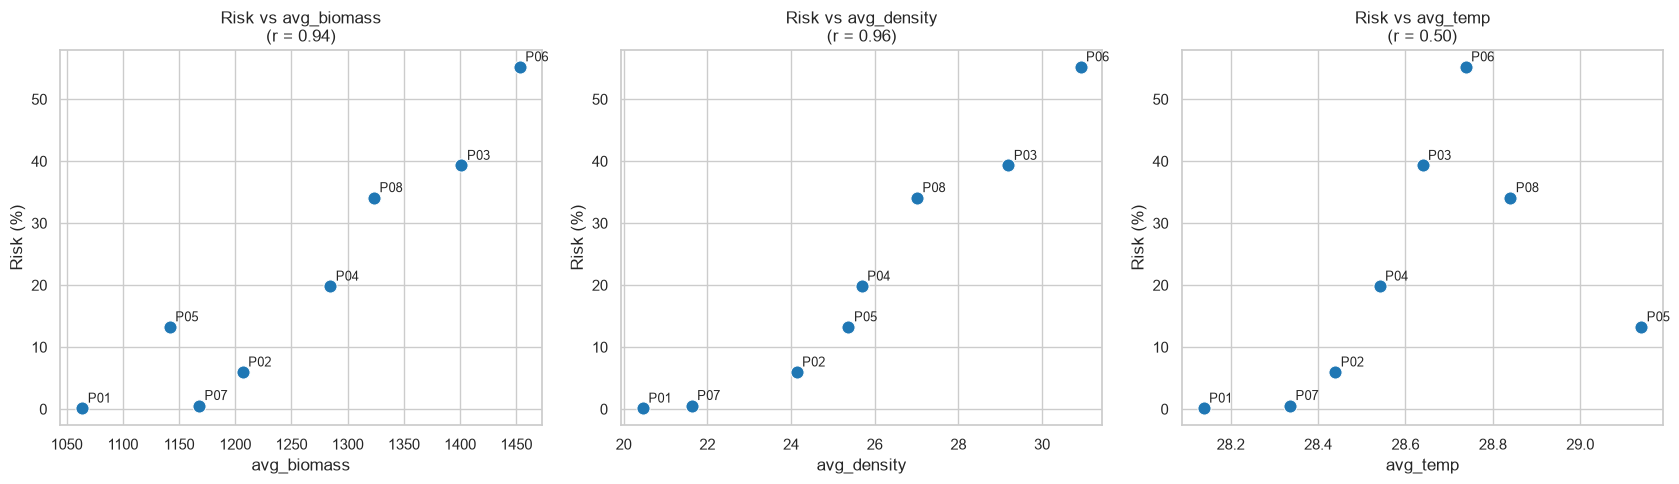

Korelasi antar-kolam (8 titik):
risk_rate        1.000
avg_biomass      0.941
avg_density      0.963
avg_temp         0.500
avg_turbidity    0.961
risk_pct         1.000
Name: risk_rate, dtype: float64


In [23]:
pond_profile = df.groupby("pond_id").agg(
    risk_rate=("risk_condition", "mean"),
    avg_biomass=("biomass_kg", "mean"),
    avg_density=("stocking_density_kg_m3", "mean"),
    avg_temp=("temperature_c", "mean"),
    avg_turbidity=("turbidity_ntu", "mean"),
).reset_index()
pond_profile["risk_pct"] = (pond_profile["risk_rate"] * 100).round(2)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, xcol in zip(axes, ["avg_biomass", "avg_density", "avg_temp"]):
    sns.scatterplot(data=pond_profile, x=xcol, y="risk_pct", ax=ax, s=90, color="#1f77b4")
    for _, r in pond_profile.iterrows():
        ax.annotate(r["pond_id"], (r[xcol], r["risk_pct"]), fontsize=9,
                    xytext=(4, 4), textcoords="offset points")
    corr = pond_profile[xcol].corr(pond_profile["risk_pct"])
    ax.set_title(f"Risk vs {xcol}\n(r = {corr:.2f})")
    ax.set_ylabel("Risk (%)")
plt.tight_layout()
plt.show()

print("Korelasi antar-kolam (8 titik):")
print(pond_profile.drop(columns="pond_id").corr(numeric_only=True)["risk_rate"].round(3))

In [24]:
ranked = pond_profile.sort_values("risk_pct", ascending=False)
top, bottom = ranked.iloc[0], ranked.iloc[-1]
print(f"{top.pond_id}: {top.risk_pct:.1f}%  vs  {bottom.pond_id}: {bottom.risk_pct:.1f}%")
print(f"Beda absolut  : {top.risk_pct - bottom.risk_pct:.1f} persen-poina")
print(f"Risk ratio    : {top.risk_pct / bottom.risk_pct:.1f}x")

P06: 55.2%  vs  P01: 0.1%
Beda absolut  : 55.1 persen-poina
Risk ratio    : 394.4x


Selisih risiko antar kolam sangat besar. P06 mencapai 55,2% sedangkan P01 cuma 0,14%, bedanya
lebih dari 55 poin persen (kalau dirasio sekitar 400 kali). Dari scatter dan korelasi antar 8
kolam, risiko naik sangat kuat seiring biomassa (r = 0,94), kepadatan tebar (r = 0,96), dan
kekeruhan (r = 0,96), sedangkan korelasi dengan suhu cuma sedang (r = 0,50). P05 yang suhunya
paling panas malah berisiko rendah, jadi suhu sepertinya bukan penentu utama.

Secara biologis masuk akal: kolam dengan biomassa dan kepadatan tinggi membuang lebih banyak
nitrogen (amonia/nitrit), sehingga nitrit gampang lewat ambang.

Tapi kami tidak mau mengklaim kausal. Kolamnya cuma 8, korelasi antar kolam jadi rapuh, dan
biomassa-kepadatan-suhu saling berkaitan (confounding). Butuh data eksperimen atau model yang
mengontrol waktu/kolam kalau mau bicara sebab-akibat.

### C.2 Aerator dan oksigen terlarut (agregat lalu distratifikasi)

In [25]:
agg = df.groupby("aerator_status")["dissolved_oxygen_mg_l"].agg(
    ["count", "mean", "median", "std"]).round(3)
print("AGREGAT:")
display(agg)

print("\nStratifikasi menurut time_period:")
display(df.groupby(["time_period", "aerator_status"])["dissolved_oxygen_mg_l"]
        .mean().unstack().round(3))

print("\nStratifikasi menurut aerator_command:")
display(df.groupby(["aerator_command", "aerator_status"])["dissolved_oxygen_mg_l"]
        .mean().unstack().round(3))

print("\nStratifikasi menurut aerator_fault:")
display(df.groupby(["aerator_fault", "aerator_status"])["dissolved_oxygen_mg_l"]
        .mean().unstack().round(3))

AGREGAT:


,count,mean,median,std
aerator_status,,,,
OFF,7878,5.472,5.49,0.801
ON,15124,5.067,4.97,0.897



Stratifikasi menurut time_period:


aerator_status,OFF,ON
time_period,,
afternoon,6.033,6.153
dawn,3.764,4.487
morning,4.977,4.902
night,5.376,5.323



Stratifikasi menurut aerator_command:


aerator_status,OFF,ON
aerator_command,,
OFF,5.552,NaN
ON,4.408,5.067



Stratifikasi menurut aerator_fault:


aerator_status,OFF,ON
aerator_fault,,
0,5.552,5.067
1,4.408,NaN


Stratifikasi menurut kelompok kepadatan:


aerator_status,OFF,ON
density_group,,
Rendah,5.643,4.998
Sedang,5.288,5.205
Tinggi,4.394,5.003


Stratifikasi menurut kolam:


aerator_status,OFF,ON
pond_id,,
P01,5.523,5.331
P02,5.442,5.222
P03,5.031,5.046
P04,5.256,5.096
P05,5.499,5.088
P06,4.782,4.919
P07,5.978,4.909
P08,5.249,5.065


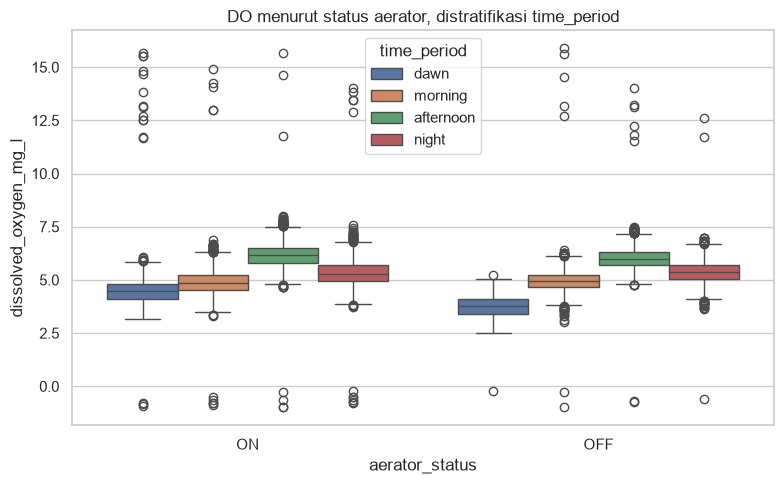

In [26]:
df["density_group"] = pd.qcut(df["stocking_density_kg_m3"], 3,
                              labels=["Rendah", "Sedang", "Tinggi"])
print("Stratifikasi menurut kelompok kepadatan:")
display(df.groupby(["density_group", "aerator_status"], observed=True)
        ["dissolved_oxygen_mg_l"].mean().unstack().round(3))

print("Stratifikasi menurut kolam:")
display(df.groupby(["pond_id", "aerator_status"])["dissolved_oxygen_mg_l"]
        .mean().unstack().round(3))

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="aerator_status", y="dissolved_oxygen_mg_l", hue="time_period")
plt.title("DO menurut status aerator, distratifikasi time_period")
plt.tight_layout()
plt.show()

Secara agregat, DO saat aerator OFF justru sedikit lebih tinggi (5,47) daripada saat ON
(5,07). Kalau dibaca mentah, seolah aerator menurunkan DO. Padahal ini contoh reverse
causality: aerator dinyalakan justru karena DO sedang turun.

Setelah distratifikasi, hasilnya berubah. Waktu dawn, DO lebih tinggi saat ON (4,49) daripada
OFF (3,76). Pada kepadatan tinggi hubungannya juga terbalik (OFF 4,39 vs ON 5,00). Jadi angka
agregat tadi muncul karena periode siang yang DO-nya tinggi kebetulan aeratornya dimatikan,
bukan karena aerator menurunkan DO.

Yang paling menjelaskan adalah strata aerator_command: DO terendah (4,41) justru terjadi saat
perintahnya ON tapi statusnya OFF, tepat kondisi fault. Semua baris aerator_fault = 1 memang
berstatus OFF dan DO-nya paling rendah (4,41 vs 5,23). Jadi penurunan DO lebih terkait
gangguan aerator (fault) daripada sekadar perintah ON/OFF. Karena command (niat operator) dan
fault (kegagalan) bercampur di kolom status, kami pisahkan keduanya lewat analisis kejadian
di C.3.

### C.3 Gangguan aerator: jendela 3 jam sebelum dan sesudah

In [27]:
df = df.sort_values(["pond_id", "timestamp"]).reset_index(drop=True)

df["fault_prev"] = df.groupby("pond_id")["aerator_fault"].shift(1)
fault_starts = df[(df["aerator_fault"] == 1) & (df["fault_prev"] != 1)][
    ["pond_id", "timestamp"]
]
print("Jumlah kejadian awal gangguan aerator:", len(fault_starts))
fault_starts.head()

Jumlah kejadian awal gangguan aerator: 479


,pond_id,timestamp
341,P01,2026-01-12 02:30:00
482,P01,2026-01-15 01:00:00
539,P01,2026-01-16 05:30:00
583,P01,2026-01-17 03:30:00
723,P01,2026-01-20 01:30:00


In [28]:
frames = []
for _, row in fault_starts.iterrows():
    pond, t0 = row["pond_id"], row["timestamp"]
    w = df[(df["pond_id"] == pond) &
           (df["timestamp"].between(t0 - pd.Timedelta(hours=3),
                                    t0 + pd.Timedelta(hours=3)))].copy()
    w["relative_hour"] = (w["timestamp"] - t0) / pd.Timedelta(hours=1)
    frames.append(w)
fault_analysis = pd.concat(frames, ignore_index=True)
print("Observasi dalam jendela gangguan:", len(fault_analysis))
fault_analysis.head()

Observasi dalam jendela gangguan: 6224


,record_id,timestamp,pond_id,day_of_cycle,hour_decimal,time_period,species,pond_volume_m3,stocking_density_kg_m3,biomass_kg,temperature_c,ph,dissolved_oxygen_mg_l,ammonia_mg_l,nitrite_mg_l,turbidity_ntu,feed_kg,aerator_command,aerator_status,aerator_fault,rainfall_mm,water_exchange_pct,sensor_quality_flag,fish_stress_event,risk_next_3h,dataset_split,cycle_phase,risk_do,risk_nh3,risk_no2,risk_condition,density_group,fault_prev,relative_hour
0,AQUA-000336,2026-01-11 23:30:00,P01,7,23.5,night,Nila,52,16.59,862.7,27.45,7.27,5.52,0.189,0.148,34.3,0.0,ON,ON,0,0.0,0,OK,0,0.0,TRAIN,Awal,False,False,False,False,Rendah,0.0,-3.0
1,AQUA-000337,2026-01-12 00:00:00,P01,8,0.0,dawn,Nila,52,16.73,870.1,27.50,7.21,5.77,0.205,0.142,33.8,0.0,ON,ON,0,0.0,0,OK,0,0.0,TRAIN,Awal,False,False,False,False,Rendah,0.0,-2.5
2,AQUA-000338,2026-01-12 00:30:00,P01,8,0.5,dawn,Nila,52,16.73,870.1,27.36,7.13,5.37,0.190,0.158,35.8,0.0,ON,ON,0,0.0,0,OK,0,0.0,TRAIN,Awal,False,False,False,False,Rendah,0.0,-2.0
3,AQUA-000339,2026-01-12 01:00:00,P01,8,1.0,dawn,Nila,52,16.73,870.1,27.32,7.15,5.26,0.157,0.145,35.5,0.0,ON,ON,0,0.0,0,OK,0,0.0,TRAIN,Awal,False,False,False,False,Rendah,0.0,-1.5
4,AQUA-000340,2026-01-12 01:30:00,P01,8,1.5,dawn,Nila,52,16.73,870.1,27.35,7.21,5.38,0.191,0.146,36.3,0.0,ON,ON,0,0.0,0,OK,0,0.0,TRAIN,Awal,False,False,False,False,Rendah,0.0,-1.0


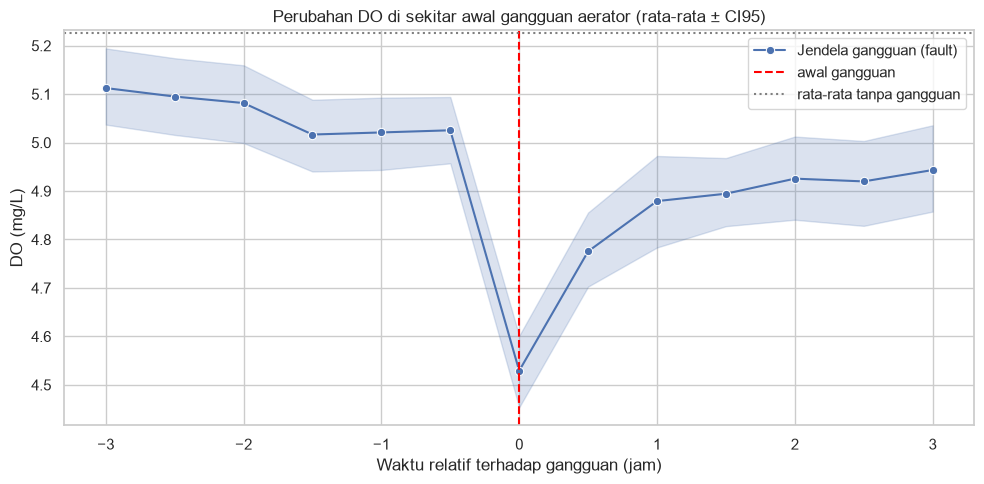

Rata-rata DO:
  Sebelum gangguan (-3..0 jam): 5.059
  Setelah gangguan (0..+3 jam): 4.838
  Tanpa gangguan (semua)      : 5.226


In [29]:
normal = df[df["aerator_fault"] == 0].copy()
normal["relative_hour"] = np.nan

plt.figure(figsize=(10, 5))
sns.lineplot(data=fault_analysis, x="relative_hour", y="dissolved_oxygen_mg_l",
             errorbar=("ci", 95), marker="o", label="Jendela gangguan (fault)")
plt.axvline(0, color="red", ls="--", label="awal gangguan")
plt.axhline(normal["dissolved_oxygen_mg_l"].mean(), color="gray", ls=":",
            label="rata-rata tanpa gangguan")
plt.title("Perubahan DO di sekitar awal gangguan aerator (rata-rata ± CI95)")
plt.xlabel("Waktu relatif terhadap gangguan (jam)")
plt.ylabel("DO (mg/L)")
plt.legend()
plt.tight_layout()
plt.show()

print("Rata-rata DO:")
print(f"  Sebelum gangguan (-3..0 jam): "
      f"{fault_analysis[fault_analysis.relative_hour < 0]['dissolved_oxygen_mg_l'].mean():.3f}")
print(f"  Setelah gangguan (0..+3 jam): "
      f"{fault_analysis[fault_analysis.relative_hour >= 0]['dissolved_oxygen_mg_l'].mean():.3f}")
print(f"  Tanpa gangguan (semua)      : {normal['dissolved_oxygen_mg_l'].mean():.3f}")

Kami mendeteksi 479 kejadian awal gangguan. Rata-rata DO sebelum gangguan 5,059, setelah
gangguan 4,838, sedangkan saat tidak ada gangguan 5,226. Jadi DO memang cenderung turun di
sekitar gangguan dan tetap tertekan sesudahnya. Ini memperkuat dugaan bahwa yang berkaitan
dengan penurunan DO adalah kegagalan aerator, bukan perintah ON/OFF biasa.

Keterbatasannya, kejadian gangguan tidak acak karena lebih banyak di kolam padat (P03, P06,
P08). Pembanding tanpa gangguan juga tidak kami cocokkan per kolam/jam, jadi sebagian efeknya
bisa saja confounding. Untuk klaim yang lebih kuat perlu matching pada kolam, jam, dan kondisi
sebelum gangguan.

### C.4 Efek tertunda pakan (lag 1-12 interval)

In [30]:
df = df.sort_values(["pond_id", "timestamp"]).reset_index(drop=True)
for i in range(1, 13):
    df[f"feed_lag_{i}"] = df.groupby("pond_id")["feed_kg"].shift(i)

lag_result = []
for i in range(1, 13):
    lag_result.append({
        "lag": i,
        "lag_jam": i * 0.5,
        "ammonia_corr": df[f"feed_lag_{i}"].corr(df["ammonia_mg_l"]),
        "nitrite_corr": df[f"feed_lag_{i}"].corr(df["nitrite_mg_l"]),
        "turbidity_corr": df[f"feed_lag_{i}"].corr(df["turbidity_ntu"]),
        "DO_corr": df[f"feed_lag_{i}"].corr(df["dissolved_oxygen_mg_l"]),
    })
lag_result = pd.DataFrame(lag_result)
lag_result.round(3)

,lag,lag_jam,ammonia_corr,nitrite_corr,turbidity_corr,DO_corr
0,1,0.5,0.030,0.032,0.114,-0.005
1,2,1.0,0.032,0.033,0.103,0.005
2,3,1.5,0.036,0.035,0.092,0.010
3,4,2.0,0.041,0.034,0.083,0.013
4,5,2.5,0.041,0.036,0.071,0.016
5,6,3.0,0.030,0.027,0.048,0.023
6,7,3.5,0.030,0.027,0.051,0.027
7,8,4.0,0.031,0.027,0.050,0.026
8,9,4.5,0.033,0.029,0.036,0.028
9,10,5.0,0.032,0.028,0.032,0.056


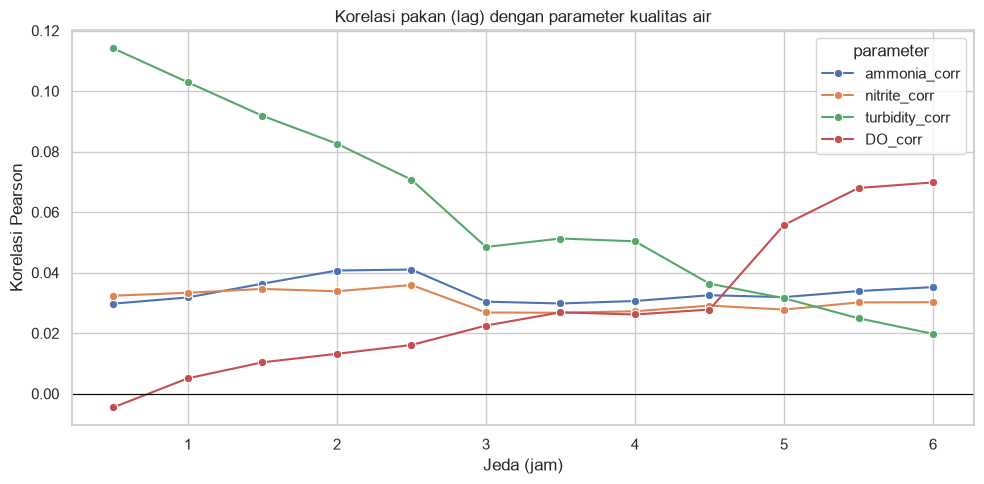

In [31]:
lag_long = lag_result.melt(id_vars=["lag", "lag_jam"],
                           value_vars=["ammonia_corr", "nitrite_corr",
                                       "turbidity_corr", "DO_corr"],
                           var_name="parameter", value_name="correlation")
plt.figure(figsize=(10, 5))
sns.lineplot(data=lag_long, x="lag_jam", y="correlation", hue="parameter", marker="o")
plt.axhline(0, color="black", lw=0.8)
plt.title("Korelasi pakan (lag) dengan parameter kualitas air")
plt.xlabel("Jeda (jam)")
plt.ylabel("Korelasi Pearson")
plt.tight_layout()
plt.show()

Korelasi pakan dengan amonia/nitrit/turbidity ternyata lemah dan tidak ada puncak lag yang
jelas; semua |r|-nya kecil. Kekeruhan sedikit lebih tinggi di lag terpendek (0,114) tapi tetap
kecil. Jadi hubungan langsung pakan ke amonia tidak kelihatan di data sintetis ini, mungkin
tertutup oleh variasi harian dan perbedaan antar kolam.

Meski begitu, fitur lag masih menarik sebagai kandidat fitur untuk Minggu 2. Yang penting,
pembuatannya harus per kolam (`groupby("pond_id").shift()`) supaya tidak menggeser data dari
kolam lain.

### C.5 Hujan: agregat dibanding stratifikasi per jam

AGREGAT:


,dissolved_oxygen_mg_l,ammonia_mg_l,nitrite_mg_l,turbidity_ntu
rain_category,,,,
Tidak hujan,5.173,0.336,0.280,49.069
Hujan ringan,5.764,0.346,0.287,53.953
Hujan lebat,5.984,0.346,0.267,58.113


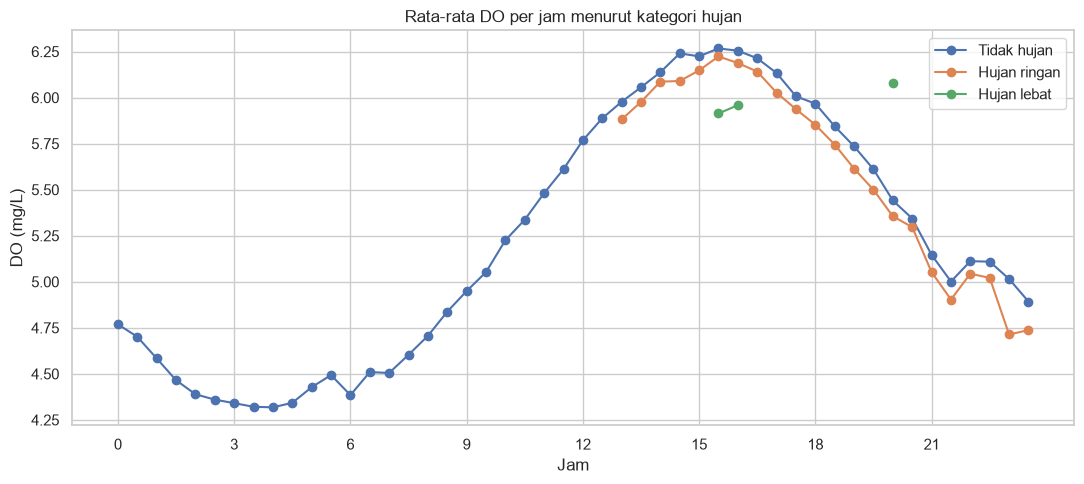

In [32]:
df["rain_category"] = pd.cut(
    df["rainfall_mm"],
    bins=[-1, 0, 10, np.inf],
    labels=["Tidak hujan", "Hujan ringan", "Hujan lebat"],
)

rain_agg = df.groupby("rain_category", observed=True)[
    ["dissolved_oxygen_mg_l", "ammonia_mg_l", "nitrite_mg_l", "turbidity_ntu"]
].mean().round(3)
print("AGREGAT:")
display(rain_agg)

rain_by_hour = (
    df.groupby(["hour_decimal", "rain_category"], observed=True)["dissolved_oxygen_mg_l"]
    .mean().unstack()
)
plt.figure(figsize=(11, 5))
for col in rain_by_hour.columns:
    plt.plot(rain_by_hour.index, rain_by_hour[col], marker="o", label=col)
plt.title("Rata-rata DO per jam menurut kategori hujan")
plt.xlabel("Jam")
plt.ylabel("DO (mg/L)")
plt.legend()
plt.xticks(range(0, 24, 3))
plt.tight_layout()
plt.show()

Secara agregat, perbedaan DO/amonia/nitrit antar kategori hujan kecil, dan kategori hujan lebat
isinya sangat sedikit sehingga rata-ratanya tidak stabil. Setelah dipecah per jam, pola DO
tetap didominasi siklus harian. Karena hujan di data ini cenderung muncul di jam tertentu,
hasil agregat bisa berbeda dari hasil per strata. Itulah kenapa stratifikasi penting, supaya
efek hujan tidak tertukar dengan efek jam. Kesimpulan kami, belum ada bukti kuat bahwa hujan
langsung mengubah kualitas air di dataset ini.

### C.6 Pertukaran air: perbandingan amonia dan nitrit sebelum vs sesudah

In [33]:
events = df[df["water_exchange_pct"] > 0][["pond_id", "timestamp", "water_exchange_pct"]]
print("Jumlah kejadian pertukaran air:", len(events))

records = []
for _, r in events.iterrows():
    for offset, label in [(-1, "Sebelum (-30m)"), (0, "Saat (t0)"),
                          (1, "Sesudah (+30m)"), (2, "Sesudah (+1j)")]:
        t = r["timestamp"] + pd.Timedelta(minutes=30 * offset)
        row = df[(df["pond_id"] == r["pond_id"]) & (df["timestamp"] == t)]
        if len(row):
            records.append({
                "pond_id": r["pond_id"], "label": label,
                "ammonia": row["ammonia_mg_l"].iloc[0],
                "nitrite": row["nitrite_mg_l"].iloc[0],
            })
exchange = pd.DataFrame(records)

print("Rata-rata sebelum/sesudah (semua kolam):")
display(exchange.groupby("label", observed=True)[["ammonia", "nitrite"]].mean().round(3))

print("Konsistensi antar-kolam (perubahan Sesudah +30m - Sebelum):")
per_pond = exchange.pivot_table(index="pond_id", columns="label",
                                values="nitrite", aggfunc="mean")
per_pond["delta_no2"] = per_pond.get("Sesudah (+30m)") - per_pond.get("Sebelum (-30m)")
display(per_pond.round(3))

Jumlah kejadian pertukaran air: 65


Rata-rata sebelum/sesudah (semua kolam):


,ammonia,nitrite
label,,
Saat (t0),0.261,0.244
Sebelum (-30m),0.338,0.292
Sesudah (+1j),0.266,0.244
Sesudah (+30m),0.261,0.242


Konsistensi antar-kolam (perubahan Sesudah +30m - Sebelum):


label,Saat (t0),Sebelum (-30m),Sesudah (+1j),Sesudah (+30m),delta_no2
pond_id,,,,,
P01,0.179,0.212,0.176,0.174,-0.038
P02,0.211,0.259,0.220,0.212,-0.048
P03,0.286,0.338,0.278,0.280,-0.057
P04,0.249,0.294,0.246,0.246,-0.048
P05,0.244,0.295,0.243,0.239,-0.055
P06,0.321,0.385,0.322,0.321,-0.064
P07,0.186,0.225,0.191,0.191,-0.034
P08,0.283,0.337,0.278,0.280,-0.057


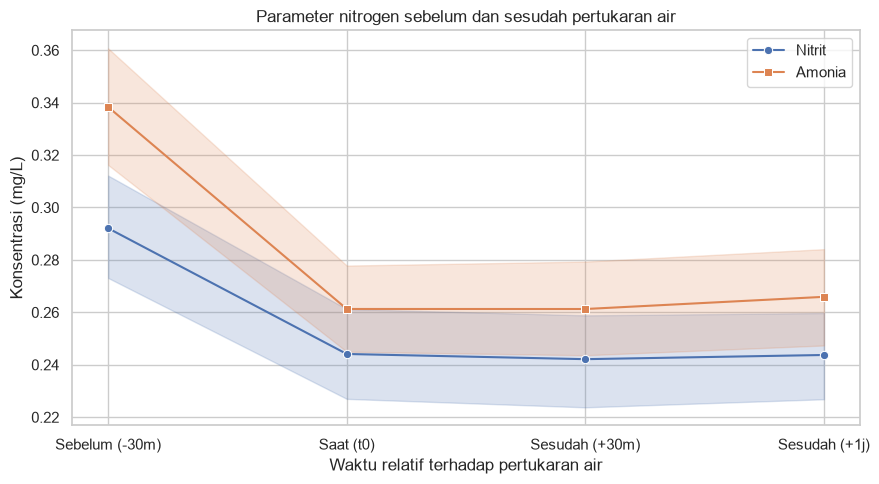

In [34]:
plt.figure(figsize=(9, 5))
sns.lineplot(data=exchange, x="label", y="nitrite", marker="o",
             errorbar=("ci", 95), label="Nitrit")
sns.lineplot(data=exchange, x="label", y="ammonia", marker="s",
             errorbar=("ci", 95), label="Amonia")
plt.title("Parameter nitrogen sebelum dan sesudah pertukaran air")
plt.xlabel("Waktu relatif terhadap pertukaran air")
plt.ylabel("Konsentrasi (mg/L)")
plt.tight_layout()
plt.show()

Ada 65 kejadian pertukaran air. Setelah dirata-rata, amonia dan nitrit turun cukup jelas tepat
setelah pertukaran (nitrit 0,292 ke 0,242 mg/L; amonia 0,338 ke 0,261 mg/L) dan bertahan
sampai sekitar satu jam. Penurunannya konsisten di kedelapan kolam, dengan perubahan nitrit
antara -0,034 sampai -0,064 mg/L.

Walaupun konsisten, efeknya sebenarnya kecil dan tidak sampai mengubah status risiko secara
drastis. Penyebabnya, sumber amonia/nitrit (biomassa, pakan, dekomposisi) tetap berjalan, dan
kolam padat seperti P06 tetap tertinggi (0,32) meski sudah diganti airnya.

Jumlah kejadian per kolam juga sedikit, jadi rata-ratanya kurang stabil. Butuh event lebih
banyak atau desain before-after-control kalau mau menyimpulkan efektivitasnya.

---
# Ringkasan Minggu 1

Ringkasan dari kami, ini poin-poin utama yang kami dapat.

Pertama, kualitas datanya sebenarnya bagus. Tidak ada duplikasi dan interval waktunya
konsisten 30 menit. Anomali tetap ada, sekitar 2,97% baris ber-flag (drift pH, DO flatline,
spike) dan 0,65% nilai sensor hilang, dan semuanya terpusat di sensor.

Kedua, risiko kualitas air lebih ditentukan karakter kolam daripada jam. Kondisinya 21,05%,
didominasi nitrit, dan menumpuk di P06/P03/P08 yang biomassa dan kepadatannya tinggi.

Ketiga, DO jelas mengikuti siklus harian (rendah saat fajar, tinggi siang). Menariknya,
penurunan DO lebih berkaitan dengan gangguan aerator (fault) daripada status ON/OFF.

Dua masalah data yang kami catat:
1. Nilai sensor hilang (147 baris SENSOR_MISSING + 2 baris MULTIPLE) di ph, DO, amonia, dan
   turbidity.
2. Anomali sensor berupa DO spike/flatline dan pH drift yang bisa menggeser statistik nilai
   ekstrem dan mempengaruhi analisis DO.

Hipotesis diagnostik yang masih perlu diuji: kegagalan aerator (fault) menyebabkan DO turun
dan memperbesar risiko dalam 3 jam berikutnya, setelah mengontrol kolam, jam, kepadatan, dan
biomassa. Ini belum kami uji secara kausal, masih perlu matching atau model dengan
pengendalian confounding.

Rencana fitur untuk model prediksi Minggu 2: sin/cos jam, lag DO/suhu/pH/amonia/nitrit
(1-12 interval, per kolam), statistik bergerak (mean/min/std/trend) yang hanya memakai masa
lalu, waktu sejak pakan dan akumulasi pakan, interaksi aerator x fault dan suhu x biomassa,
serta indikator sensor_quality_flag. Aturannya, record_id, risk_next_3h, dataset_split, dan
informasi masa depan tidak boleh jadi fitur; species konstan; fish_stress_event hanya untuk
deskriptif/diagnostik.